## 실습용 데이터 파일 업로드
아래 셀을 실행하여 컴퓨터에 저장된 9개의 엑셀 파일들을 선택해 주세요.
(필요 파일: `OCV_exp_charge.xlsx`, `OCV_exp_discharge.xlsx`, `DST_current.xlsx`, `DST_voltage.xlsx`, `OCV_soc_data.xlsx`, `DST_estimation_current.xlsx`, `DST_estimation_voltage.xlsx`, `DST_estimation_soc.xlsx` 등)

In [ ]:
from google.colab import files
import os

# 파일 업로드
print("실습에 필요한 9개의 Excel 파일들을 모두 선택하여 업로드해주세요.")
uploaded = files.upload()

# 업로드된 파일 확인 및 경로 설정
BASE_DIR = '/content'
for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

# 파일 존재 여부 체크 함수
def check_file(name):
    path = os.path.join(BASE_DIR, name)
    if not os.path.exists(path):
        print(f"[주의] {name} 파일이 업로드되지 않았습니다.")
    return path

실습에 필요한 9개의 Excel 파일들을 모두 선택하여 업로드해주세요.


Saving DST_current.xlsx to DST_current.xlsx
Saving DST_estimation_current.xlsx to DST_estimation_current.xlsx
Saving DST_estimation_soc.xlsx to DST_estimation_soc.xlsx
Saving DST_estimation_voltage.xlsx to DST_estimation_voltage.xlsx
Saving DST_SOC.xlsx to DST_SOC.xlsx
Saving DST_voltage.xlsx to DST_voltage.xlsx
Saving OCV_exp_charge.xlsx to OCV_exp_charge.xlsx
Saving OCV_exp_discharge.xlsx to OCV_exp_discharge.xlsx
Saving OCV_soc_data.xlsx to OCV_soc_data.xlsx
User uploaded file "DST_current.xlsx" with length 46325 bytes
User uploaded file "DST_estimation_current.xlsx" with length 349196 bytes
User uploaded file "DST_estimation_soc.xlsx" with length 390566 bytes
User uploaded file "DST_estimation_voltage.xlsx" with length 389964 bytes
User uploaded file "DST_SOC.xlsx" with length 90704 bytes
User uploaded file "DST_voltage.xlsx" with length 65378 bytes
User uploaded file "OCV_exp_charge.xlsx" with length 307817 bytes
User uploaded file "OCV_exp_discharge.xlsx" with length 306535 bytes

---

## Part 1: OCV 추정 및 데이터 분석

배터리의 개방 회로 전압(OCV)과 SOC 간의 비선형적인 관계를 정의하기 위해 다양한 환경 조건(예: 온도)에서 데이터를 수집하고 분석하는 과정입니다.

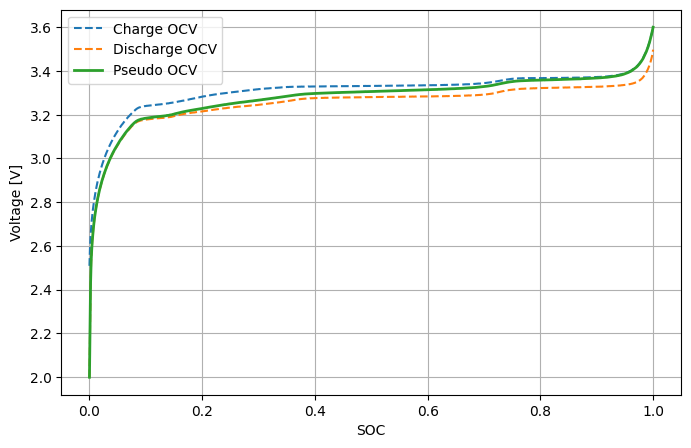

In [ ]:
# === 엑셀 데이터 기반 OCV 계산 (업로드된 파일명 반영) ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 업로드 시 이름이 변경된 것을 고려하여 경로 설정
charge_path = '/content/OCV_exp_charge (1).xlsx' if os.path.exists('/content/OCV_exp_charge (1).xlsx') else '/content/OCV_exp_charge.xlsx'
dischg_path = '/content/OCV_exp_discharge (1).xlsx' if os.path.exists('/content/OCV_exp_discharge (1).xlsx') else '/content/OCV_exp_discharge.xlsx'

charge_df = pd.read_excel(charge_path, header=None)
dischg_df = pd.read_excel(dischg_path, header=None)

C_V = charge_df.iloc[:, 1].dropna().to_numpy().astype(float)
D_V = dischg_df.iloc[:, 1].dropna().to_numpy().astype(float)

def sample_1001(x):
    if len(x) == 0: raise ValueError("데이터가 비어있습니다.")
    idx = np.linspace(0, len(x)-1, 1001).round().astype(int)
    return x[idx]

OCV_C = sample_1001(C_V)
OCV_D = sample_1001(D_V)[::-1]
SOC = np.linspace(0.0, 1.0, 1001)
OCV_est = SOC * OCV_C + (1.0 - SOC) * OCV_D

plt.figure(figsize=(8, 5))
plt.plot(SOC, OCV_C, '--', label='Charge OCV')
plt.plot(SOC, OCV_D, '--', label='Discharge OCV')
plt.plot(SOC, OCV_est, label='Pseudo OCV', linewidth=2)
plt.xlabel('SOC'); plt.ylabel('Voltage [V]'); plt.legend(); plt.grid(True); plt.show()

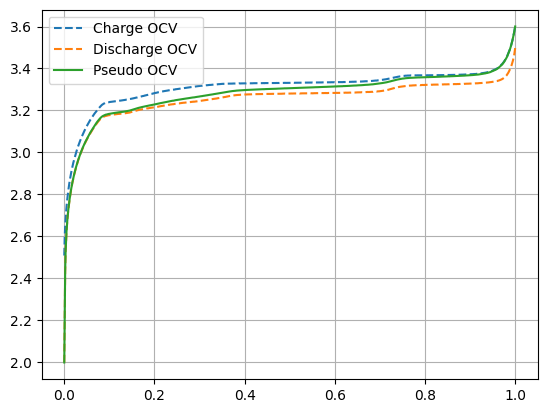

In [ ]:
# === 로컬 업로드 데이터 기반 경로 재설정 (수정본) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Google Drive 대신 로컬 경로 사용
charge_path = os.path.join(BASE_DIR, 'OCV_exp_charge.xlsx')
dischg_path = os.path.join(BASE_DIR, 'OCV_exp_discharge.xlsx')

# 이후 로직은 동일하게 진행
charge_df = pd.read_excel(charge_path, header=None)
dischg_df = pd.read_excel(dischg_path, header=None)

C_V = charge_df.iloc[:, 1].dropna().to_numpy().astype(float)
D_V = dischg_df.iloc[:, 1].dropna().to_numpy().astype(float)

def sample_1001(x):
    idx = np.linspace(0, len(x)-1, 1001).round().astype(int)
    return x[idx]

OCV_C = sample_1001(C_V)
OCV_D = sample_1001(D_V)[::-1]
SOC = np.linspace(0.0, 1.0, 1001)
OCV_est = SOC * OCV_C + (1.0 - SOC) * OCV_D

plt.figure()
plt.plot(SOC, OCV_C, '--', label='Charge OCV')
plt.plot(SOC, OCV_D, '--', label='Discharge OCV')
plt.plot(SOC, OCV_est, label='Pseudo OCV')
plt.legend(); plt.grid(True); plt.show()

DST 실험 데이터 플롯

In [ ]:
# === DST 데이터 로컬 경로 설정 ===
import os
BASE_DIR = '/content'
CURR_FILE = os.path.join(BASE_DIR, 'DST_current.xlsx')
VOLT_FILE = os.path.join(BASE_DIR, 'DST_voltage.xlsx')

print('Current file exists:', os.path.exists(CURR_FILE))
print('Voltage file exists:', os.path.exists(VOLT_FILE))

Current file exists: True
Voltage file exists: True


In [ ]:
# === DST 데이터 로컬 경로 설정 ===
CURR_FILE = os.path.join(BASE_DIR, 'DST_current.xlsx')
VOLT_FILE = os.path.join(BASE_DIR, 'DST_voltage.xlsx')

print('Current file exists:', os.path.exists(CURR_FILE))
print('Voltage file exists:', os.path.exists(VOLT_FILE))

Current file exists: True
Voltage file exists: True


Estimated capacity: 0.685 Ah
SOC range: 0.000 – 1.000
dt used: 1.0000 s


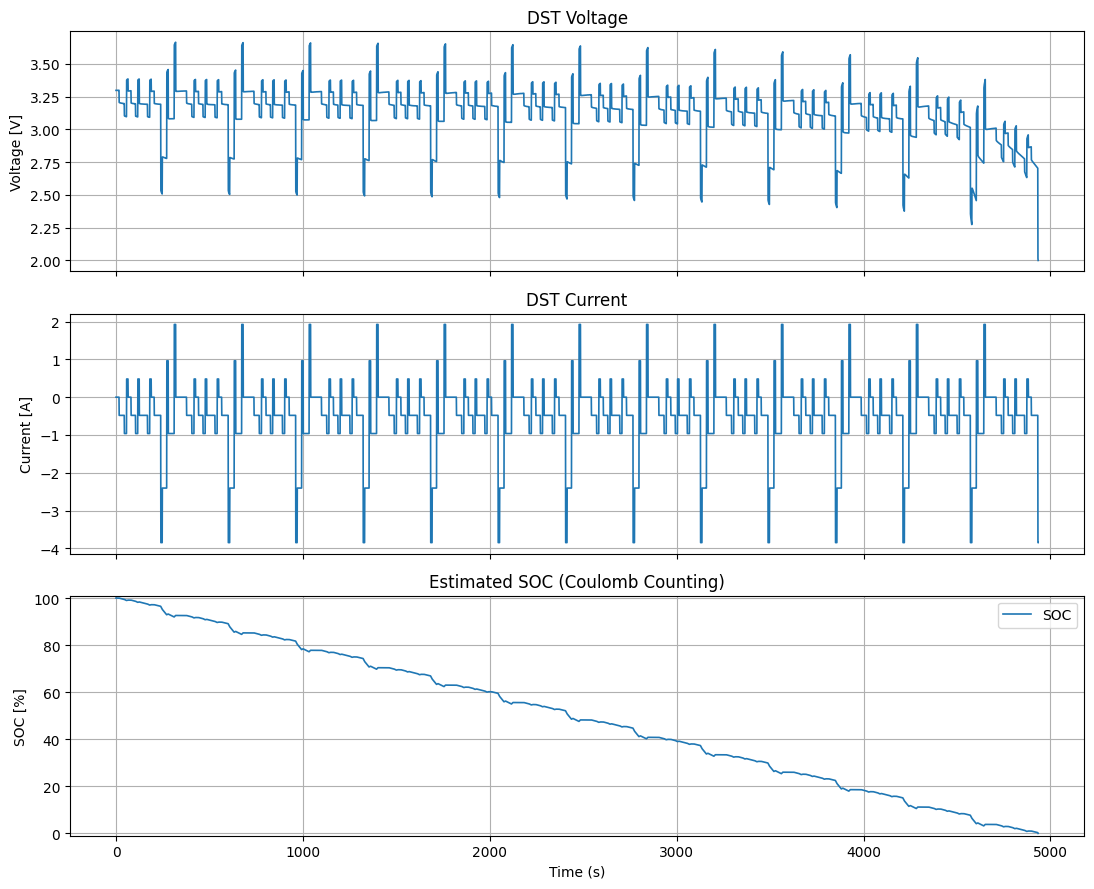

In [ ]:
# === Read Excel -> SOC -> Plots ===========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def read_series_from_excel(path):
    """
    엑셀을 읽어 (t, y) 반환.
    - 1열만 있으면: t=None, y=그 열
    - 2열 이상이면: 1열=시간(단조 비감소면 채택), 마지막 열=신호
    - 숫자 이외는 무시(coerce) → header 유무와 상관없이 동작
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f'Not found: {path}')
    df = pd.read_excel(path, header=None)
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(how='all').dropna(axis=1, how='all').reset_index(drop=True)
    if df.shape[1] == 0:
        raise ValueError(f'No numeric columns found in {path}')

    if df.shape[1] == 1:
        y = df.iloc[:, 0].to_numpy(dtype=float).ravel()
        t = None
    else:
        t_candidate = df.iloc[:, 0].to_numpy(dtype=float).ravel()
        is_monotone = np.all(np.diff(t_candidate) >= 0)
        if is_monotone:
            t = t_candidate
            y = df.iloc[:, -1].to_numpy(dtype=float).ravel()
        else:
            t = None
            y = df.iloc[:, -1].to_numpy(dtype=float).ravel()
    return t, y

# 1) Load Excel (전류/전압)
t_I, I = read_series_from_excel(CURR_FILE)  # [A], 방전>0 가정
t_V, V = read_series_from_excel(VOLT_FILE)  # [V]

# 2) 공통 시간축
if t_I is not None:
    t = t_I
elif t_V is not None:
    t = t_V
else:
    N = min(len(I), len(V))
    t = np.arange(N, dtype=float)  # 1초 간격 가정

# 3) 길이 맞추기
N = min(len(t), len(I), len(V))
t = t[:N]; I = I[:N]; V = V[:N]

# 4) dt 추정 (없으면 1초)
if N >= 2 and np.all(np.diff(t) > 0):
    dt = float(np.median(np.diff(t)))
else:
    dt = 1.0

# 5) 용량/ SOC (MATLAB 로직의 일반화: dt 반영)
capacity_Ah = -np.sum(I) * dt / 3600.0
SOC_DST = (capacity_Ah + np.cumsum(I) * dt / 3600.0) / capacity_Ah
SOC_DST = np.clip(SOC_DST, 0.0, 1.0)

print(f"Estimated capacity: {capacity_Ah:.3f} Ah")
print(f"SOC range: {SOC_DST.min():.3f} – {SOC_DST.max():.3f}")
print(f"dt used: {dt:.4f} s")

# 6) Plot: Voltage & Current (twin y-axis), SOC
fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

# (1) Voltage
axs[0].plot(t, V, linewidth=1.2)
axs[0].set_ylabel('Voltage [V]')
axs[0].set_title('DST Voltage')
axs[0].grid(True)

# (2) Current
axs[1].plot(t, I, linewidth=1.2)
axs[1].set_ylabel('Current [A]')
axs[1].set_title('DST Current')
axs[1].grid(True)

# (3) SOC
axs[2].plot(t, SOC_DST*100, linewidth=1.2, label='SOC')
axs[2].set_xlabel('Time (s)' if dt==1.0 else 'Time (from Excel)')
axs[2].set_ylabel('SOC [%]')
axs[2].set_ylim(-1, 101)
axs[2].grid(True)
axs[2].legend(loc='best')
axs[2].set_title('Estimated SOC (Coulomb Counting)')

plt.tight_layout()
plt.show()


---

## Part 2: ECM 모델 구축

OCV 소스, 내부 저항, 그리고 확산 효과를 나타내는 RC 회로 등으로 구성된 등가 회로 모델을 설계하여 배터리 셀의 전기적 거동을 수학적으로 표현합니다.

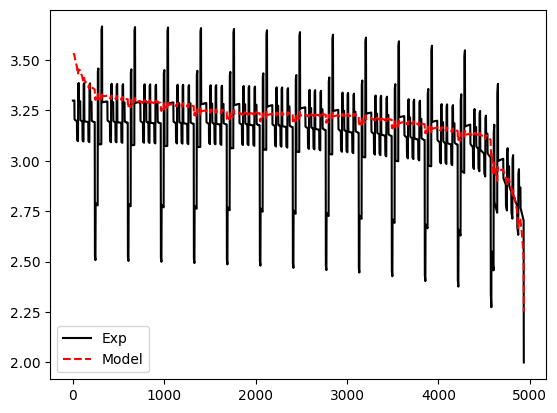

In [ ]:
# === ECM 모델 구축 (로컬 경로 사용) ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# 경로 설정
CURR_XLSX = '/content/DST_current.xlsx'
VOLT_XLSX = '/content/DST_voltage.xlsx'
OCV_XLSX  = '/content/OCV_soc_data.xlsx'

# [도우미 함수 및 ECM 로직은 기존과 동일]
def read_first_col_xlsx(path):
    df = pd.read_excel(path, header=None)
    return pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna().to_numpy(dtype=float)

def load_ocv_from_xlsx(path):
    df = pd.read_excel(path, header=None)
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    soc, ocv = df.iloc[:, 0].to_numpy(), df.iloc[:, 1].to_numpy()
    return PchipInterpolator(soc[np.argsort(soc)], ocv[np.argsort(soc)], extrapolate=True)

def ecm_1rc_voltage(I, R0, R1, C1, ocv_fn, capacity_Ah=0.6849, init_SOC=0.999, dt=1.0):
    I = np.asarray(I).ravel(); N = I.size; a = np.exp(-dt/(R1*C1))
    SOC = np.zeros(N); ir1 = np.zeros(N); V = np.zeros(N)
    SOC[0] = init_SOC; V[0] = float(ocv_fn(SOC[0])) + I[0]*R0
    for k in range(1, N):
        SOC[k] = np.clip(SOC[k-1] + (I[k]*dt/3600)/capacity_Ah, 0, 1)
        ir1[k] = a*ir1[k-1] + (1-a)*I[k]
        V[k] = float(ocv_fn(SOC[k])) + ir1[k]*R1 + I[k]*R0
    return V, SOC

# 실행
I_exp = read_first_col_xlsx(CURR_XLSX)
V_exp = read_first_col_xlsx(VOLT_XLSX)
ocv_fn = load_ocv_from_xlsx(OCV_XLSX)

V_model, SOC_model = ecm_1rc_voltage(I_exp, 0.01, 0.155, 4400.0, ocv_fn)
plt.plot(V_exp, 'k', label='Exp'); plt.plot(V_model, '--r', label='Model'); plt.legend(); plt.show()

In [ ]:
# === ECM 모델용 로컬 경로 설정 (파일 이름 수정 및 함수 재선언) ===
import os
import pandas as pd
import numpy as np
from scipy.interpolate import PchipInterpolator

def read_first_col_xlsx(path):
    df = pd.read_excel(path, header=None)
    return pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna().to_numpy(dtype=float)

def load_ocv_from_xlsx(path):
    df = pd.read_excel(path, header=None)
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    soc, ocv = df.iloc[:, 0].to_numpy(), df.iloc[:, 1].to_numpy()
    return PchipInterpolator(soc[np.argsort(soc)], ocv[np.argsort(soc)], extrapolate=True)

# (1) 접미사 붙은 파일 우선 확인
CURR_XLSX = '/content/DST_current (1).xlsx' if os.path.exists('/content/DST_current (1).xlsx') else '/content/DST_current.xlsx'
VOLT_XLSX = '/content/DST_voltage (1).xlsx' if os.path.exists('/content/DST_voltage (1).xlsx') else '/content/DST_voltage.xlsx'
OCV_XLSX  = '/content/OCV_soc_data (1).xlsx' if os.path.exists('/content/OCV_soc_data (1).xlsx') else '/content/OCV_soc_data.xlsx'

# 데이터 로드
I_exp = read_first_col_xlsx(CURR_XLSX)
V_exp = read_first_col_xlsx(VOLT_XLSX)
ocv_fn = load_ocv_from_xlsx(OCV_XLSX)

---

## Part 3: 파라미터 최적화

구축된 ECM의 저항 및 커패시터 파라미터가 배터리의 실제 동작 특성(SOC, 온도 등)을 가장 잘 모사하도록 최적화하는 단계입니다.


Fitted parameters:
  R0 = 0.203552 Ohm
  R1 = 0.101737 Ohm
  C1 = 1174.911 F
RMSE before: 0.11867 V
RMSE after : 0.03793 V


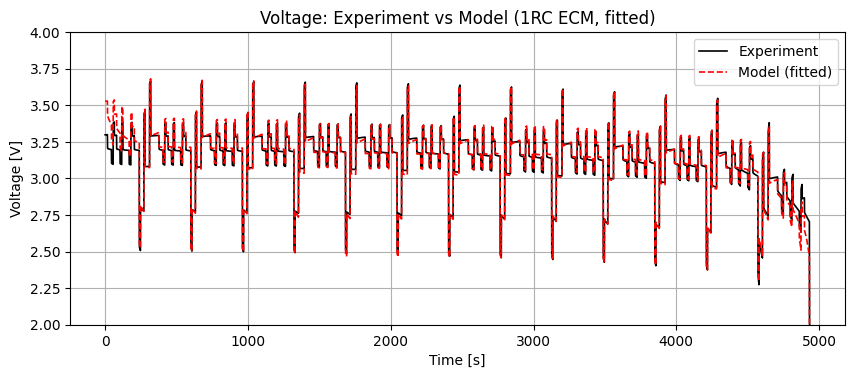

In [ ]:
# === 1RC ECM parameter optimization (least squares, dt=1 s) ===
# Fits: R0, R1, C1  (capacity_Ah and init_SOC are kept fixed)
# Objective: minimize RMSE between V_model and V_exp

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# --- Initial guesses ---
R0_init = 0.110   # Ohm
R1_init = 0.055   # Ohm
C1_init = 4400.0  # F

# --- Fixed constants ---
capacity_Ah_fixed = 0.684940966109617
init_SOC_fixed    = 0.999
dt                = 1.0

# --- Residual function for least squares ---
def residual_theta(theta):
    R0, R1, C1 = theta
    if R0 <= 0 or R1 <= 0 or C1 <= 0:
        return 1e3 * np.ones_like(V_exp)
    V_hat, _ = ecm_1rc_voltage(
        I_exp, R0, R1, C1, ocv_fn,
        capacity_Ah=capacity_Ah_fixed,
        init_SOC=init_SOC_fixed,
        dt=dt
    )
    return (V_hat - V_exp)

theta0  = np.array([R0_init, R1_init, C1_init], dtype=float)
lower   = np.array([1e-4,   1e-4,    1e2   ])
upper   = np.array([0.5,     2.0,     1e6   ])

res = least_squares(
    residual_theta, theta0, bounds=(lower, upper),
    method='trf', loss='linear', verbose=0, max_nfev=500
)

R0_opt, R1_opt, C1_opt = res.x
print("\nFitted parameters:")
print(f"  R0 = {R0_opt:.6f} Ohm")
print(f"  R1 = {R1_opt:.6f} Ohm")
print(f"  C1 = {C1_opt:.3f} F")

# --- Re-simulate with optimal parameters ---
V_opt, SOC_opt = ecm_1rc_voltage(
    I_exp, R0_opt, R1_opt, C1_opt, ocv_fn,
    capacity_Ah=capacity_Ah_fixed,
    init_SOC=init_SOC_fixed,
    dt=dt
)

# RMSE calculation
rmse_before = np.sqrt(np.mean((V_exp - ecm_1rc_voltage(I_exp, R0_init, R1_init, C1_init, ocv_fn, capacity_Ah=capacity_Ah_fixed, init_SOC=init_SOC_fixed, dt=dt)[0])**2))
rmse_after  = np.sqrt(np.mean((V_exp - V_opt)**2))
print(f"RMSE before: {rmse_before:.5f} V")
print(f"RMSE after : {rmse_after:.5f} V")

# Plots
plt.figure(figsize=(10, 3.8))
plt.plot(t, V_exp, '-k', lw=1.2, label='Experiment')
plt.plot(t, V_opt, '--r', lw=1.2, label='Model (fitted)')
plt.xlabel('Time [s]'); plt.ylabel('Voltage [V]')
plt.title('Voltage: Experiment vs Model (1RC ECM, fitted)')
plt.ylim(2, 4); plt.grid(True); plt.legend(); plt.show()

---

## Part 4: EKF 기반 SOC 추정

앞서 구축된 ECM과 최적화된 파라미터를 기반으로 EKF 알고리즘을 적용하여, 실시간으로 측정되는 배터리의 전압 및 전류 데이터를 이용하여 SOC를 정밀하게 추정하고 오차를 보정합니다.

In [ ]:
# === EKF SOC 추정 (로컬 경로 사용) ===
CURR_XLSX = '/content/DST_estimation_current.xlsx'
VOLT_XLSX = '/content/DST_estimation_voltage.xlsx'
SOCG_XLSX = '/content/DST_estimation_soc.xlsx'
OCV_XLSX  = '/content/OCV_soc_data.xlsx'

# 데이터 로드
I = read_first_col_xlsx(CURR_XLSX)
V_meas = read_first_col_xlsx(VOLT_XLSX)
SOC_true = read_first_col_xlsx(SOCG_XLSX)
ocv_fn = load_ocv_from_xlsx(OCV_XLSX)

print(f"Data loaded: I({len(I)}), V({len(V_meas)}), SOC_true({len(SOC_true)})")
# 이후 EKF 로직 수행...

Data loaded: I(4935), V(4935), SOC_true(4935)


In [ ]:
# === EKF용 로컬 경로 설정 (파일 이름 수정) ===
import os
CURR_XLSX = '/content/DST_estimation_current (1).xlsx' if os.path.exists('/content/DST_estimation_current (1).xlsx') else '/content/DST_estimation_current.xlsx'
VOLT_XLSX = '/content/DST_estimation_voltage (1).xlsx' if os.path.exists('/content/DST_estimation_voltage (1).xlsx') else '/content/DST_estimation_voltage.xlsx'
SOCG_XLSX = '/content/DST_estimation_soc (1).xlsx' if os.path.exists('/content/DST_estimation_soc (1).xlsx') else '/content/DST_estimation_soc.xlsx'
OCV_XLSX  = '/content/OCV_soc_data (1).xlsx' if os.path.exists('/content/OCV_soc_data (1).xlsx') else '/content/OCV_soc_data.xlsx'

I = read_first_col_xlsx(CURR_XLSX)
V_meas = read_first_col_xlsx(VOLT_XLSX)
SOC_true = read_first_col_xlsx(SOCG_XLSX)
ocv_fn = load_ocv_from_xlsx(OCV_XLSX)

In [ ]:
# === EKF Core Algorithm Implementation ===
import numpy as np

# Optimized parameters from previous step
R0, R1, C1 = R0_opt, R1_opt, C1_opt
a = np.exp(-dt/(R1*C1))
capacity_Ah = capacity_Ah_fixed
docv_fn = ocv_fn.derivative()

def run_ekf(init_soc_est, init_ir1_est=0.0, Q_diag=(1e-7, 1e-6), R_var=1e-3, P0_diag=(0.01, 0.01)):
    N = len(I)
    x_hat = np.zeros((2, N))
    V_est = np.zeros(N)
    P = np.diag(P0_diag)
    Q = np.diag(Q_diag)
    Rm = np.array([[R_var]])

    x_hat[:, 0] = [init_soc_est, init_ir1_est]

    for k in range(1, N):
        # Predict
        soc_pred = x_hat[0, k-1] + (I[k]*dt/3600)/capacity_Ah
        ir1_pred = a * x_hat[1, k-1] + (1-a) * I[k]
        soc_pred = np.clip(soc_pred, 0, 1)

        F = np.array([[1, 0], [0, a]])
        P = F @ P @ F.T + Q

        # Update
        dOCV = float(docv_fn(soc_pred))
        H = np.array([[dOCV, R1]])
        y_pred = float(ocv_fn(soc_pred)) + R1*ir1_pred + R0*I[k]

        K = P @ H.T @ np.linalg.inv(H @ P @ H.T + Rm)
        innovation = V_meas[k] - y_pred

        x_upd = np.array([soc_pred, ir1_pred]) + (K @ np.array([[innovation]])).ravel()
        x_upd[0] = np.clip(x_upd[0], 0, 1)

        x_hat[:, k] = x_upd
        P = (np.eye(2) - K @ H) @ P
        V_est[k] = y_pred

    return x_hat[0, :], V_est

# Run scenarios
INIT_SOC_A = 0.999
INIT_SOC_B = 0.900
SOC_A, V_A = run_ekf(INIT_SOC_A)
SOC_B, V_B = run_ekf(INIT_SOC_B)

print("EKF calculation complete. Now you can run the visualization cells below.")

EKF calculation complete. Now you can run the visualization cells below.


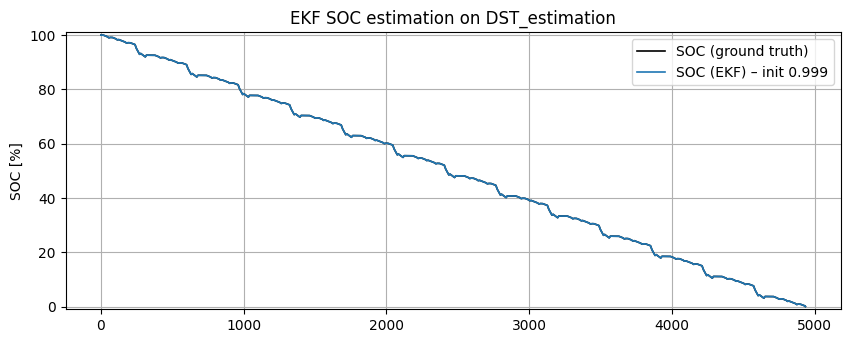

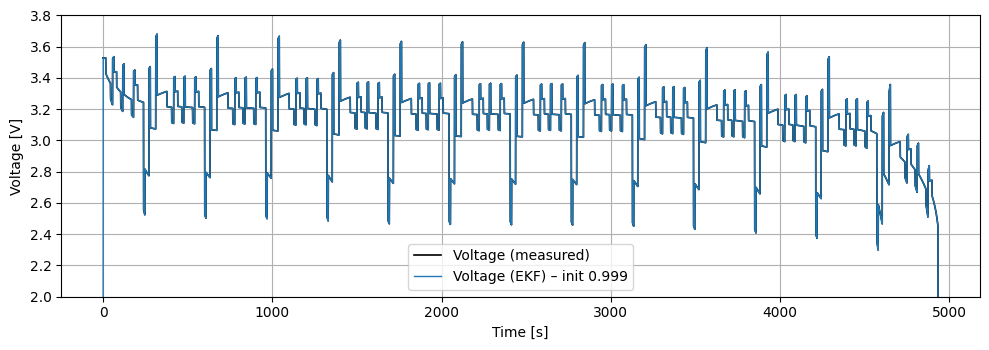

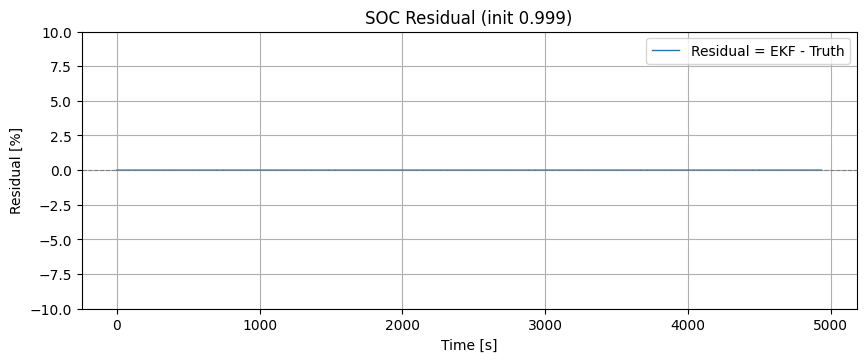

In [ ]:
# (1) SOC / voltage estimation (No initial error)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3.6))
plt.plot(t, SOC_true*100, 'k-', lw=1.2, label='SOC (ground truth)')
plt.plot(t, SOC_A*100,   '-',  lw=1.2, label='SOC (EKF) – init 0.999')
plt.ylim(-1, 101)
plt.ylabel('SOC [%]')
plt.title('EKF SOC estimation on DST_estimation')
plt.grid(True); plt.legend(loc='best')

plt.figure(figsize=(10,3.6))
plt.plot(t, V_meas, 'k-', lw=1.2, label='Voltage (measured)')
plt.plot(t, V_A,    '-',  lw=1.0, label='Voltage (EKF) – init 0.999')
plt.ylim(2, 3.8)
plt.xlabel('Time [s]'); plt.ylabel('Voltage [V]')
plt.grid(True); plt.legend(loc='best')
plt.tight_layout(); plt.show()

# Residual = SOC_est - SOC_true
residual_A = SOC_A - SOC_true
plt.figure(figsize=(10,3.6))
plt.plot(t, residual_A*100, lw=1.0, label='Residual = EKF - Truth')
plt.ylim(-10, 10)
plt.axhline(0.0, ls='--', lw=0.8, color='gray')
plt.xlabel('Time [s]')
plt.ylabel('Residual [%]')
plt.title(f'SOC Residual (init {INIT_SOC_A:.3f})')
plt.grid(True); plt.legend(loc='best')
plt.show()

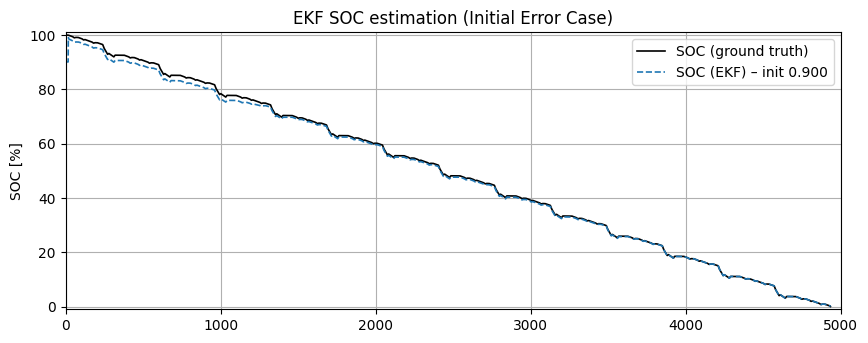

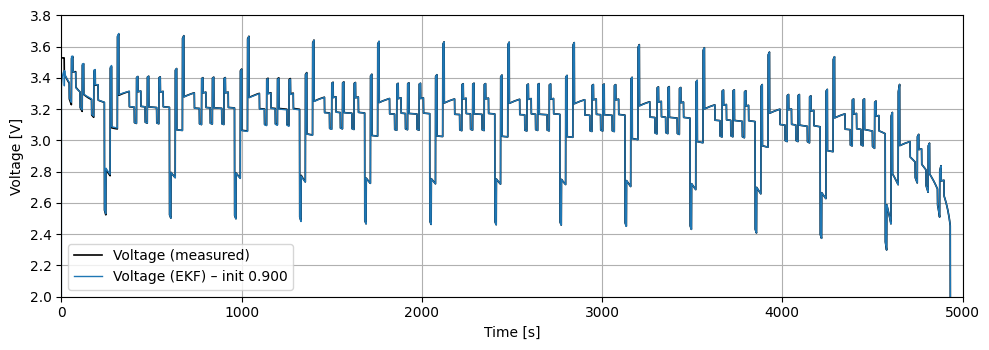

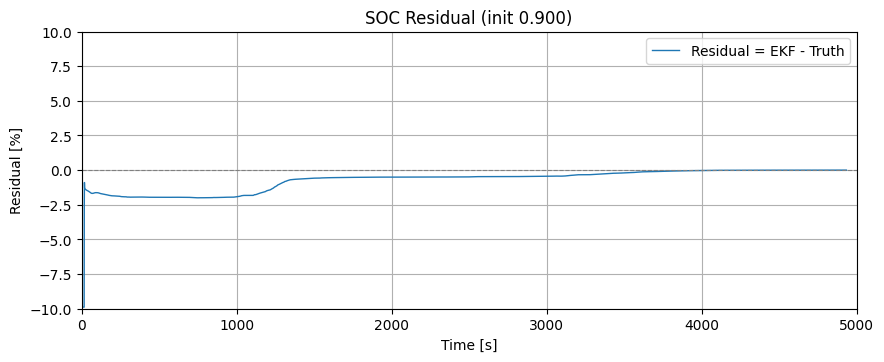

In [ ]:
# (2) SOC / voltage estimation (10 % initial error)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3.6))
plt.plot(t, SOC_true*100, 'k-', lw=1.2, label='SOC (ground truth)')
plt.plot(t, SOC_B*100,   '--', lw=1.2, label='SOC (EKF) – init 0.900')
plt.ylim(-1, 101)
plt.xlim(0, 5000)
plt.ylabel('SOC [%]')
plt.title('EKF SOC estimation (Initial Error Case)')
plt.grid(True); plt.legend(loc='best')

plt.figure(figsize=(10,3.6))
plt.plot(t, V_meas, 'k-', lw=1.2, label='Voltage (measured)')
plt.plot(t, V_B,    '-',  lw=1.0, label='Voltage (EKF) – init 0.900')
plt.xlim(0, 5000)
plt.ylim(2, 3.8)
plt.xlabel('Time [s]'); plt.ylabel('Voltage [V]')
plt.grid(True); plt.legend(loc='best')
plt.tight_layout(); plt.show()

residual_B = SOC_B - SOC_true
plt.figure(figsize=(10,3.6))
plt.plot(t, residual_B*100, lw=1.0, label='Residual = EKF - Truth')
plt.axhline(0.0, ls='--', lw=0.8, color='gray')
plt.ylim(-10, 10)
plt.xlim(0, 5000)
plt.xlabel('Time [s]')
plt.ylabel('Residual [%]')
plt.title(f'SOC Residual (init {INIT_SOC_B:.3f})')
plt.grid(True); plt.legend(loc='best')
plt.show()